# Convolutional Nueral Networks and Computer Vision with TensorFlow

CV: algorithms that can discover patterns in visual data

## Get the data

In [ ]:
import zipfile

!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

# Unzip the downloaded file
with zipfile.ZipFile('pizza_steak.zip') as zip_ref:
  zip_ref.extractall()

--2026-05-12 10:13:41--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.137.207, 142.250.101.207, 142.250.141.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.137.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip.1’

pizza_steak.zip.1   100%[===================>] 104.47M   179MB/s    in 0.6s    

2026-05-12 10:13:42 (179 MB/s) - ‘pizza_steak.zip.1’ saved [109540975/109540975]



## Inspect the data

Always inspect the data to understand how it is stored, and how it should be represented

In [ ]:
!ls pizza_steak/train/steak/

1000205.jpg  1647351.jpg  2238681.jpg  2824680.jpg  3375959.jpg  417368.jpg
100135.jpg   1650002.jpg  2238802.jpg  2825100.jpg  3381560.jpg  4176.jpg
101312.jpg   165639.jpg   2254705.jpg  2826987.jpg  3382936.jpg  42125.jpg
1021458.jpg  1658186.jpg  225990.jpg   2832499.jpg  3386119.jpg  421476.jpg
1032846.jpg  1658443.jpg  2260231.jpg  2832960.jpg  3388717.jpg  421561.jpg
10380.jpg    165964.jpg   2268692.jpg  285045.jpg   3389138.jpg  438871.jpg
1049459.jpg  167069.jpg   2271133.jpg  285147.jpg   3393547.jpg  43924.jpg
1053665.jpg  1675632.jpg  227576.jpg   2855315.jpg  3393688.jpg  440188.jpg
1068516.jpg  1678108.jpg  2283057.jpg  2856066.jpg  3396589.jpg  442757.jpg
1068975.jpg  168006.jpg   2286639.jpg  2859933.jpg  339891.jpg	 443210.jpg
1081258.jpg  1682496.jpg  2287136.jpg  286219.jpg   3417789.jpg  444064.jpg
1090122.jpg  1684438.jpg  2291292.jpg  2862562.jpg  3425047.jpg  444709.jpg
1093966.jpg  168775.jpg   229323.jpg   2865730.jpg  3434983.jpg  447557.jpg
1098844.jpg  1697

In [ ]:
import os

# Walk through the directory and list number of files
for dirpath, dirname, filenames in os.walk('pizza_steak'):
  print(f'There are {len(dirname)} directories and {len(filenames)} images in - {dirpath}')

There are 2 directories and 0 images in - pizza_steak
There are 2 directories and 0 images in - pizza_steak/test
There are 0 directories and 250 images in - pizza_steak/test/steak
There are 0 directories and 250 images in - pizza_steak/test/pizza
There are 2 directories and 0 images in - pizza_steak/train
There are 0 directories and 750 images in - pizza_steak/train/steak
There are 0 directories and 750 images in - pizza_steak/train/pizza


In [ ]:
num_steak_images_train = len(os.listdir('pizza_steak/train/steak'))
num_steak_images_train

750

Visualize images using the class names

In [ ]:
# Get the class names programatically
from pathlib import Path
import numpy as np
data_dir = Path('pizza_steak/train')
# Grab everything within the folder, extract only the latest child
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['pizza' 'steak']


In [ ]:
# Visualize images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):
  # Setup the target directory
  target_folder = target_dir + target_class

  # Get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)
  print(random_image)

  # Read in the image and plot it
  img = mpimg.imread(target_folder + '/' + random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis('off')

  # Show image shape
  print(f'Image shape: {img.shape}')

  return img

['970073.jpg']
Image shape: (512, 512, 3)


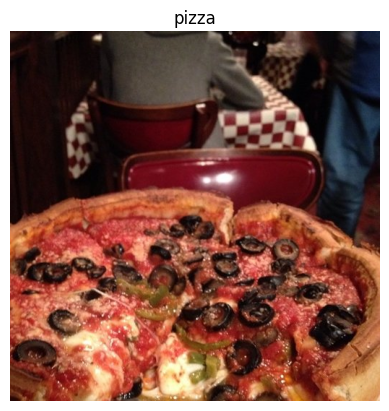

In [ ]:
# View random image from train data

img = view_random_image(target_dir='pizza_steak/train/',
                        target_class='pizza')

In [ ]:
img.shape

(512, 512, 3)

### Normalizing the data

In [ ]:
# Get all the pixel values between 0 and 1
img/255.

array([[[0.16862745, 0.05490196, 0.03921569],
        [0.18431373, 0.07058824, 0.05490196],
        [0.18823529, 0.07843137, 0.0627451 ],
        ...,
        [0.09411765, 0.15686275, 0.25882353],
        [0.08627451, 0.14901961, 0.25098039],
        [0.07843137, 0.14117647, 0.24313725]],

       [[0.18823529, 0.0745098 , 0.05882353],
        [0.19607843, 0.08235294, 0.06666667],
        [0.2       , 0.09019608, 0.0745098 ],
        ...,
        [0.08235294, 0.14509804, 0.24705882],
        [0.07058824, 0.13333333, 0.23529412],
        [0.0627451 , 0.1254902 , 0.22745098]],

       [[0.21960784, 0.10588235, 0.08235294],
        [0.21960784, 0.10588235, 0.08235294],
        [0.21960784, 0.10588235, 0.08235294],
        ...,
        [0.08235294, 0.14509804, 0.24705882],
        [0.0745098 , 0.1372549 , 0.23921569],
        [0.06666667, 0.12941176, 0.23137255]],

       ...,

       [[0.14901961, 0.02745098, 0.01568627],
        [0.14901961, 0.02745098, 0.01568627],
        [0.14901961, 0

## End-to-End example

Building a CNN to find patterns in the images:
- Load images
- Preprocess
- Build a CNN to find patterns in images
- Compile CNN
- Fit CNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# set the seed
tf.random.set_seed(42)

# Preprocess data (get all the values between 0 and 1)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Setup paths for the directories
train_dir = 'pizza_steak/train/'
test_dir = 'pizza_steak/test/'

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               batch_size=32,
                                               target_size=(224,224),
                                               class_mode='binary',
                                               seed=42)

valid_data = valid_datagen.flow_from_directory(directory=test_dir,
                                               batch_size=32,
                                               target_size=(224,224),
                                               seed=42,
                                               class_mode='binary')

# Build a CNN model (same as Tiny VGG on the CNN explainer website)
model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=10, kernel_size=3, activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(10, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2, padding='valid'),
    tf.keras.layers.Conv2D(10,3,activation='relu'),
    tf.keras.layers.Conv2D(10,3,activation='relu'),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')
    ])

# Compile the model
model_1.compile(
    loss=tf.keras.losses.BinaryCrossentropy,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

# Fit the model
history_1 = model_1.fit(train_data, epochs=5, steps_per_epoch=len(train_data), validation_data=valid_data, validation_steps=len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 176ms/step - accuracy: 0.7047 - loss: 0.5757 - val_accuracy: 0.8240 - val_loss: 0.4158
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - accuracy: 0.8053 - loss: 0.4466 - val_accuracy: 0.8480 - val_loss: 0.3550
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - accuracy: 0.8207 - loss: 0.4094 - val_accuracy: 0.8460 - val_loss: 0.3427
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.8260 - loss: 0.3940 - val_accuracy: 0.7940 - val_loss: 0.4357
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.8260 - loss: 0.3748 - val_accuracy: 0.8320 - val_loss: 0.3613


In [ ]:
model_1.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

### Use a classification model used for make circles seperation

In [ ]:
# Set seed
tf.random.set_seed(42)

# Creata model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224,224,3)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

# Compile the model
model_2.compile(
    loss='binary_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)

# Fit model
history_2 = model_2.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 134ms/step - accuracy: 0.5000 - loss: 0.8836 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932


In [ ]:
# Get a summary of new model
model_2.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │       602,116 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,806,425 (6.89 MB)

 Trainable params: 602,141 (2.30 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,204,284 (4.59 MB)

Despite having 20x more parameters than model_1, this is still bad

In [ ]:
# Set seed
tf.random.set_seed(42)

# Create the model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224,224,3)),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

# Compile
model_3.compile(
    loss='binary_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)

# fit
model_3.fit(train_data,
            epochs=5,
            steps_per_epoch=len(train_data),
            validation_data=valid_data,
            validation_steps=len(valid_data))



Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 125ms/step - accuracy: 0.6120 - loss: 4.6296 - val_accuracy: 0.6380 - val_loss: 1.2568
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.7213 - loss: 0.8177 - val_accuracy: 0.7840 - val_loss: 0.4618
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - accuracy: 0.7320 - loss: 0.6362 - val_accuracy: 0.7060 - val_loss: 0.7700
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.7520 - loss: 0.6455 - val_accuracy: 0.6580 - val_loss: 0.9073
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.7740 - loss: 0.5278 - val_accuracy: 0.7800 - val_loss: 0.4358


In [ ]:
model_3.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)            │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 100)            │    15,052,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,219,605 (172.50 MB)

 Trainable params: 15,073,201 (57.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,146,404 (115.00 MB)

Trainable parameters are patterns that the model can learn from data. Sometimes more parameters does not equate to more performance

## Binary Classification:

- Become one with the data
- Preprocess the data (batch it)
- Create a model
- Fit the model
- Evaluate the model
- Adjust different parameters to beat SOTA
- Repeat until satisfied

### 1. Become one with the data

['482022.jpg']
Image shape: (512, 512, 3)
['898843.jpg']
Image shape: (512, 512, 3)


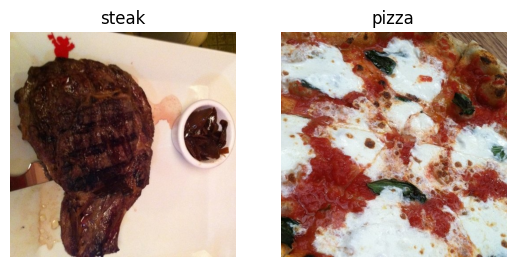

In [ ]:
# Visualize the data
plt.figure()
plt.subplot(1,2,1)
steak_img = view_random_image('pizza_steak/train/', 'steak')
plt.subplot(1,2,2)
steak_img = view_random_image('pizza_steak/train/', 'pizza')

### 2. Preprocess the data and prepare it for model

In [ ]:
# Define the paths
train_dir = 'pizza_steak/train/'
test_dir = 'pizza_steak/test'

# Trun data into batches - memory constraint, more times of gradient desc for same data

In [ ]:
# Create train and test data generators and resclae data
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

In [ ]:
# load in image data from direcctories
train_data = train_datagen.flow_from_directory(directory=train_dir, # traget_dir
                                               target_size=(224, 224), # output_size
                                               class_mode='binary', # type of classification/data
                                               batch_size=32) # Size of mini-batches/ images per batch

test_data = test_datagen.flow_from_directory(directory=test_dir,
                                             target_size=(224,224),
                                             class_mode='binary',
                                             batch_size=32)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [ ]:
# Get a sample of a train data batch
images, labels = next(train_data) # Get to the next batch of images and labels
len(images), len(labels)

(32, 32)

In [ ]:
len(train_data), len(test_data)

(47, 16)

In [ ]:
1500/32, 500/32

(46.875, 15.625)

In [ ]:
# Get the first 2 images
images[:2], images[0].shape

(array([[[[0.56078434, 0.63529414, 0.79215693],
          [0.5647059 , 0.6392157 , 0.7960785 ],
          [0.5647059 , 0.6392157 , 0.80392164],
          ...,
          [0.07843138, 0.08235294, 0.05882353],
          [0.08235294, 0.08235294, 0.07450981],
          [0.09803922, 0.09803922, 0.09803922]],
 
         [[0.5647059 , 0.6392157 , 0.7960785 ],
          [0.5568628 , 0.6313726 , 0.7960785 ],
          [0.5568628 , 0.6313726 , 0.7960785 ],
          ...,
          [0.09803922, 0.10196079, 0.07058824],
          [0.0627451 , 0.06666667, 0.04705883],
          [0.04313726, 0.04313726, 0.03529412]],
 
         [[0.5686275 , 0.6431373 , 0.8078432 ],
          [0.5647059 , 0.6392157 , 0.80392164],
          [0.5647059 , 0.6392157 , 0.8078432 ],
          ...,
          [0.07450981, 0.07843138, 0.04705883],
          [0.15686275, 0.16078432, 0.13725491],
          [0.21568629, 0.21960786, 0.20000002]],
 
         ...,
 
         [[0.3921569 , 0.34901962, 0.22352943],
          [0.39607

In [ ]:
# View the first batch of labels
labels

array([0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 0., 0., 1., 1., 1., 0., 0.,
       0., 0., 1., 1., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1.],
      dtype=float32)

### 3. Create a CNN model

Start with a baseline : existing model with existing result. Increamentally iterate and beat the baseline performance

In [ ]:
# Make the creating of our model a little easier
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation
from tensorflow.keras import Sequential as seq

In [ ]:
# Create a basesline model
model_4 = seq([
    Conv2D(filters=10,kernel_size=3,strides=1,padding='valid',activation='relu',input_shape=(224,224,3)), # valid -> otuput shape will be compressed, same -> output shape = input shape
    Conv2D(10,3,activation='relu'),
    Conv2D(10,3,activation='relu'),
    Flatten(),
    Dense(1, activation='sigmoid')
])

#### Complie the CNN model

In [ ]:
model_4.compile(
    loss='binary_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

In [ ]:
# Get teh summary
model_4.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_38 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 218, 218, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 475240)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │       475,241 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477,341 (1.82 MB)

 Trainable params: 477,341 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

### 4. Fit the CNN model

In [ ]:
# Check the lengths of train and test data gen
len(train_data), len(test_data)

(47, 16)

In [ ]:
# Fit the model
history_4 = model_4.fit(
    train_data,
    epochs=5,
    steps_per_epoch=len(train_data),
    validation_data=test_data,
    validation_steps=len(test_data)
)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - accuracy: 0.6060 - loss: 0.7550 - val_accuracy: 0.7500 - val_loss: 0.5183
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.8060 - loss: 0.4223 - val_accuracy: 0.7760 - val_loss: 0.4455
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - accuracy: 0.8840 - loss: 0.3170 - val_accuracy: 0.7440 - val_loss: 0.5037
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.9600 - loss: 0.1459 - val_accuracy: 0.7560 - val_loss: 0.5278
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.9907 - loss: 0.0465 - val_accuracy: 0.8020 - val_loss: 0.5650


In [ ]:
model_1.evaluate(test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.8320 - loss: 0.3613


[0.36125582456588745, 0.8320000171661377]

### 5. Evaluating our model

It looks like our model is learning something lets evaluate it

<Axes: >

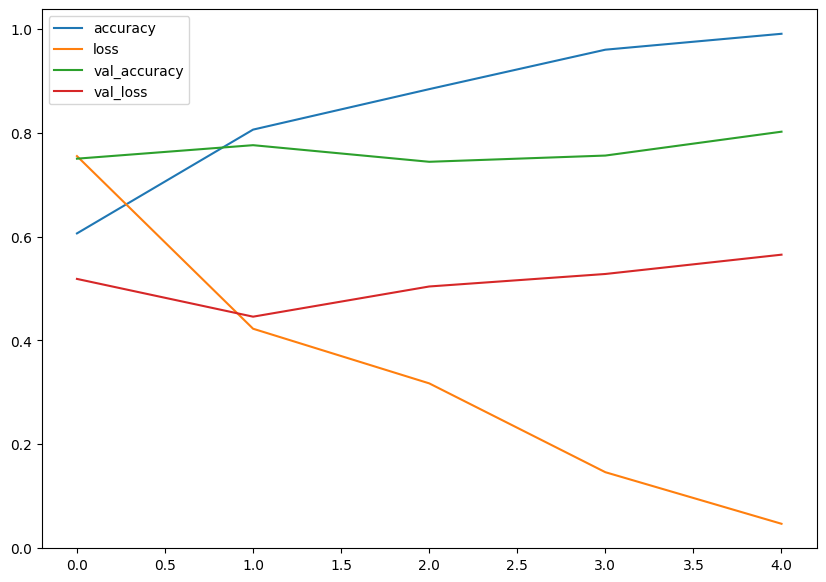

In [ ]:
import pandas as pd
pd.DataFrame(history_4.history).plot(figsize=(10,7))

In [ ]:
# Plot the validation and training curves separately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics
  """
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('loss')
  plt.xlabel('epochs')
  plt.legend()

  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('accuracy')
  plt.xlabel('epochs')
  plt.legend()

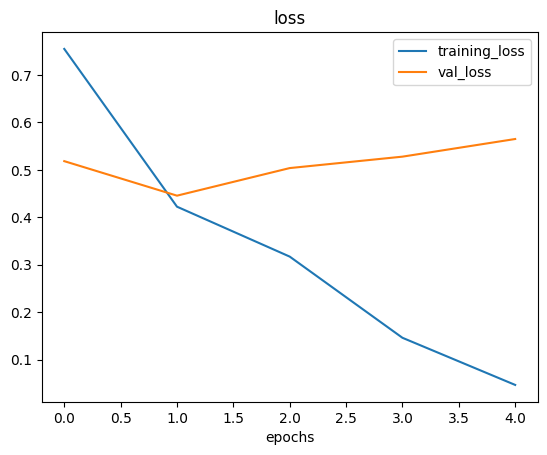

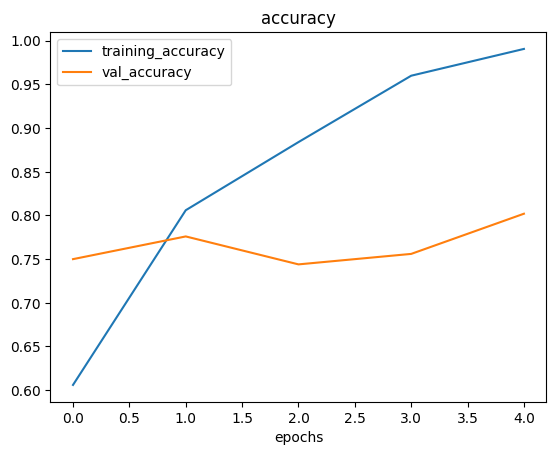

In [ ]:
plot_loss_curves(history_4)

When a models validation loss starts to increase, it's likely that the model is overfitting the training data. Learning the patterns in the training dataset too well.

Bad generalization on unseen data

### 6. Adjust the model parameters

Fitting the ML model:
- Create a baseline
- Beat the baseline by overfitting a larger model
- Reduce overfitting

Ways to induce overfitting:
1. Increase the number of conv layers
2. Increase the number of conv filters
3. Add another dense layer to the output of the `Flattened()`

Reduce overfitting:
- Add data augmentation
- Add regularization layers
- Add more data

In [ ]:
# Create the model (new baseline)
model_5 = seq([
    Conv2D(10,3,activation='relu',input_shape=(224,224,3)),
    MaxPool2D(pool_size=2),
    Conv2D(10,3,activation='relu'),
    MaxPool2D(),
    Conv2D(10,3,activation='relu'),
    MaxPool2D(),
    Conv2D(10,3,activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the model
model_5.compile(
    loss='binary_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

history_5 = model_5.fit(train_data,
              steps_per_epoch=len(train_data),
              validation_data=test_data,
              validation_steps=len(test_data),
              epochs=5)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 178ms/step - accuracy: 0.5993 - loss: 0.6670 - val_accuracy: 0.7360 - val_loss: 0.5682
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.7453 - loss: 0.5416 - val_accuracy: 0.7760 - val_loss: 0.4735
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 152ms/step - accuracy: 0.7907 - loss: 0.4691 - val_accuracy: 0.8020 - val_loss: 0.4099
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.8073 - loss: 0.4450 - val_accuracy: 0.8360 - val_loss: 0.3929
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.8093 - loss: 0.4273 - val_accuracy: 0.8340 - val_loss: 0.3817


In [ ]:
model_5.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_41 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 109, 109, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 52, 52, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 26, 26, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 24, 24, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 1440)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │         1,441 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,355 (52.17 KB)

 Trainable params: 4,451 (17.39 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,904 (34.79 KB)

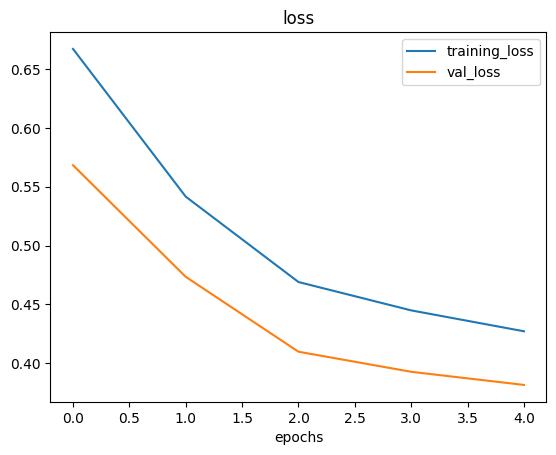

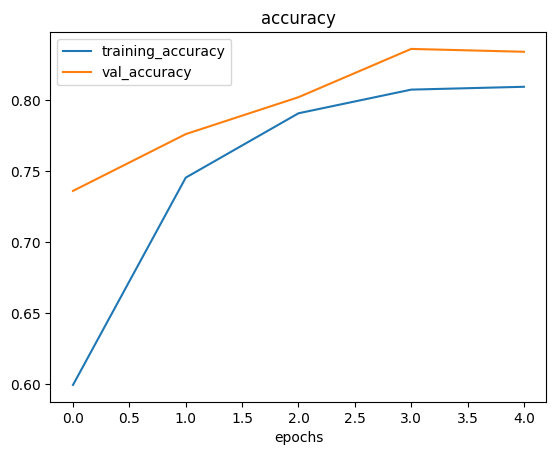

In [ ]:
# Plot loss curvers
plot_loss_curves(history_5)

### Opening our bag of tricks and finding data augmentation

In [ ]:
# Create Image DataGenerator training instance with data augmentation
train_datagen_augmented = ImageDataGenerator(
    rescale=1/255.,
    rotation_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

# Create the Image Data Generator wtihout data augmentation
train_datagen = ImageDataGenerator(rescale=1/255.)

test_datagen = ImageDataGenerator(rescale=1/255.)

In [ ]:
# Import data and augment it from training directory
print('Augmented training data')
train_data_augmented = train_datagen_augmented.flow_from_directory(directory=train_dir,
                                                                   target_size=(224,224),
                                                                   batch_size=32,
                                                                   class_mode='binary',
                                                                   shuffle=False)

train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               target_size=(224,224),
                                               shuffle=False,
                                               class_mode='binary',
                                               batch_size=32)

test_data = test_datagen.flow_from_directory(batch_size=32,
                                             class_mode='binary',
                                             directory=test_dir,
                                             target_size=(224,224))

Augmented training data
Found 1500 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [ ]:
# Get sample augmented data
images, labels = next(train_data)

augmented_images, _ = next(train_data_augmented)

Showing orginal image:  3
Showing Augmented Image 3


Text(0.5, 1.0, 'Augmented Image')

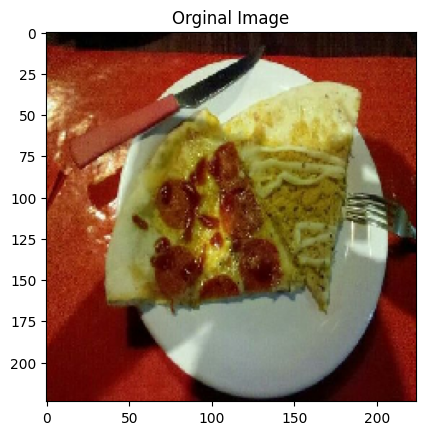

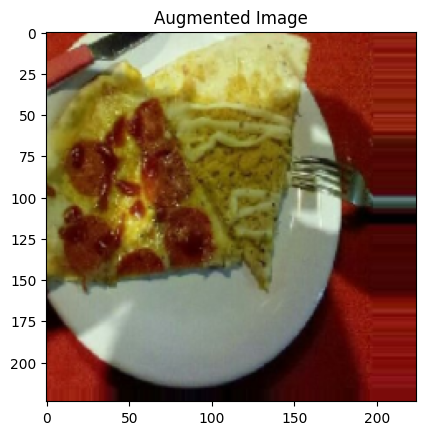

In [ ]:
# show the original image and augmented image
random_number = random.randint(0,32) # inside the batch
print('Showing orginal image: ', random_number)
plt.imshow(images[random_number])
plt.title('Orginal Image')

plt.figure()
plt.imshow(augmented_images[random_number])
print('Showing Augmented Image', random_number)
plt.title('Augmented Image')

In [ ]:
# Create a model
model_6 = seq([
    Conv2D(10,3,activation='relu', input_shape=(224,224,3)),
    MaxPool2D(),
    Conv2D(10,3,activation='relu'),
    MaxPool2D(),
    Conv2D(10,3,activation='relu'),
    MaxPool2D(),
    Conv2D(10,3,activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation='sigmoid')
])

model_6.compile(
    loss = 'binary_crossentropy',
    optimizer = Adam(),
    metrics=['accuracy']
)

In [ ]:
history_6 = model_6.fit(
    train_data_augmented,
    steps_per_epoch=len(train_data_augmented),
    validation_data=valid_data,
    validation_steps=len(valid_data),
    epochs=5
)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 553ms/step - accuracy: 0.5000 - loss: 0.7020 - val_accuracy: 0.5080 - val_loss: 0.6926
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 443ms/step - accuracy: 0.4807 - loss: 0.6936 - val_accuracy: 0.5060 - val_loss: 0.6916
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 421ms/step - accuracy: 0.5313 - loss: 0.6928 - val_accuracy: 0.6680 - val_loss: 0.6881
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 446ms/step - accuracy: 0.5820 - loss: 0.7001 - val_accuracy: 0.5200 - val_loss: 0.6684
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 423ms/step - accuracy: 0.6560 - loss: 0.6743 - val_accuracy: 0.6520 - val_loss: 0.6258


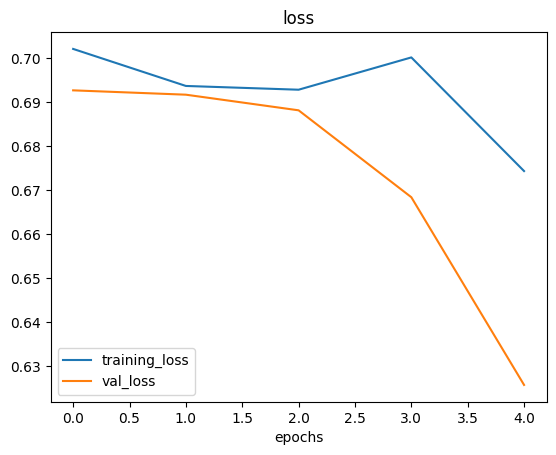

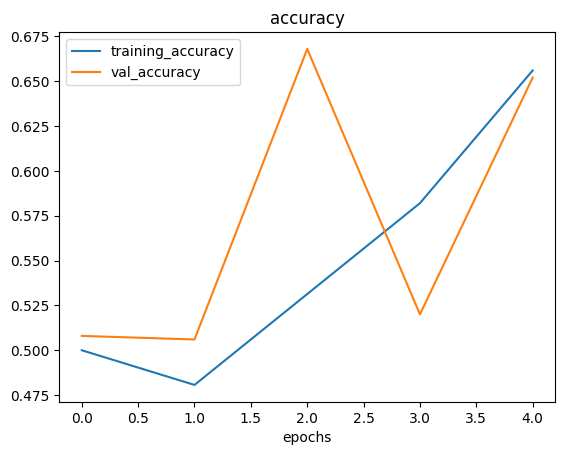

In [ ]:
# Check models training curves
plot_loss_curves(history_6)

make the data generators again and shufffle it this time, so we can get better training results

In [ ]:
# Import data and augment it + shuffle it
train_data_augmented_shuffled = train_datagen_augmented.flow_from_directory(
    directory=train_dir,
    batch_size=32,
    shuffle=True,
    target_size=(224,224),
    class_mode='binary'
)


Found 1500 images belonging to 2 classes.


In [ ]:
# Create a model same as before
model_7 = seq([
    Conv2D(10,3,activation='relu',input_shape=(224,224,3)),
    MaxPool2D(),
    Conv2D(10,3,activation='relu'),
    MaxPool2D(),
    Conv2D(10,3,activation='relu'),
    MaxPool2D(),
    Conv2D(10,3,activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(1,activation='sigmoid')
])

model_7.compile(
    loss='binary_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

In [ ]:
history_7 = model_7.fit(
    train_data_augmented_shuffled,
    epochs=5,
    steps_per_epoch=len(train_data_augmented_shuffled),
    validation_data=test_data,
    validation_steps=len(test_data)
)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 498ms/step - accuracy: 0.5720 - loss: 0.6828 - val_accuracy: 0.7100 - val_loss: 0.6359
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 421ms/step - accuracy: 0.6860 - loss: 0.5957 - val_accuracy: 0.8000 - val_loss: 0.4598
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 444ms/step - accuracy: 0.7567 - loss: 0.5147 - val_accuracy: 0.8380 - val_loss: 0.3826
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 453ms/step - accuracy: 0.7647 - loss: 0.5054 - val_accuracy: 0.8400 - val_loss: 0.3941
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 419ms/step - accuracy: 0.7773 - loss: 0.4936 - val_accuracy: 0.8400 - val_loss: 0.3953


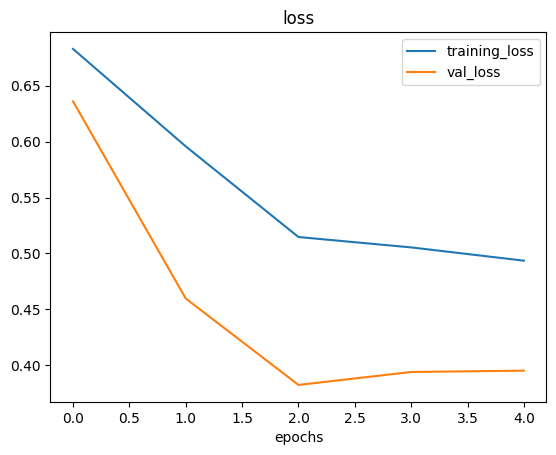

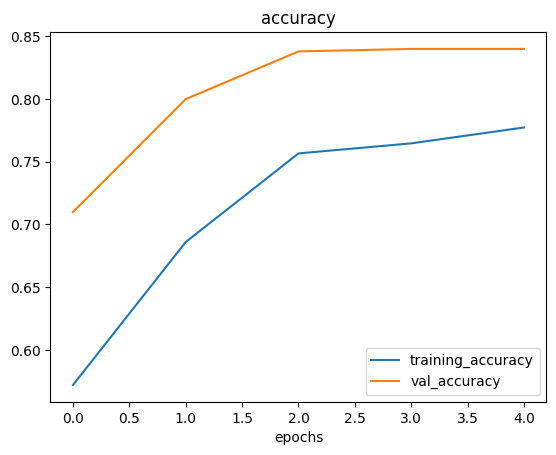

In [ ]:
# Plot the model curves
plot_loss_curves(history_7)

### 7. Repeat until satisfied

Since we have beaten the baseline, there are a few things to try out to make it better:
- add more Cov2D and MaxPool layers
- More filters with Conv2D
- Train for longer
- More data
- Use transfer learning

In [ ]:
## CNN explainer model
model = seq([
    Conv2D(32, 3, activation='relu', input_shape=(224,224,3)),
    Conv2D(32, 3, activation='relu'),
    MaxPool2D(),
    Conv2D(32, 3, activation='relu'),
    Conv2D(32, 3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

history = model.fit(
    train_data_augmented_shuffled,
    steps_per_epoch=len(train_data_augmented_shuffled),
    validation_data=test_data,
    validation_steps=len(test_data),
    epochs=30
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 39s 755ms/step - accuracy: 0.6927 - loss: 0.5844 - val_accuracy: 0.8060 - val_loss: 0.4278
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 505ms/step - accuracy: 0.7833 - loss: 0.4930 - val_accuracy: 0.8580 - val_loss: 0.3616
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 510ms/step - accuracy: 0.7553 - loss: 0.4985 - val_accuracy: 0.8120 - val_loss: 0.4173
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 30s 643ms/step - accuracy: 0.7880 - loss: 0.4695 - val_accuracy: 0.8320 - val_loss: 0.3546
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 501ms/step - accuracy: 0.8087 - loss: 0.4394 - val_accuracy: 0.8640 - val_loss: 0.3242
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 450ms/step - accuracy: 0.7953 - loss: 0.4468 - val_accuracy: 0.8360 - val_loss: 0.3334
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 476ms/step - accuracy: 0.8093 - loss: 0.4292 - val_accuracy: 0.8660 - val_loss: 0.3285
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 502ms/step - accuracy: 0.8273 - loss: 0.4119 - val_accu

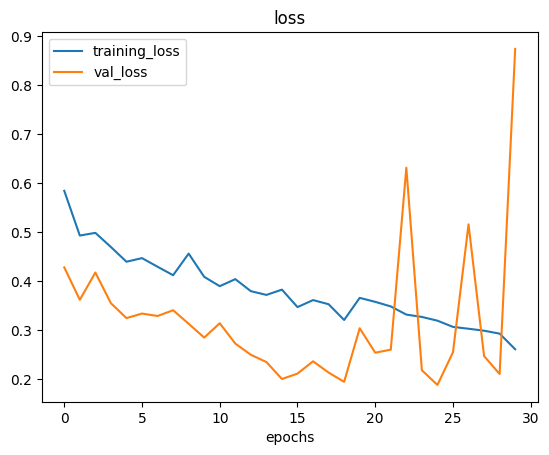

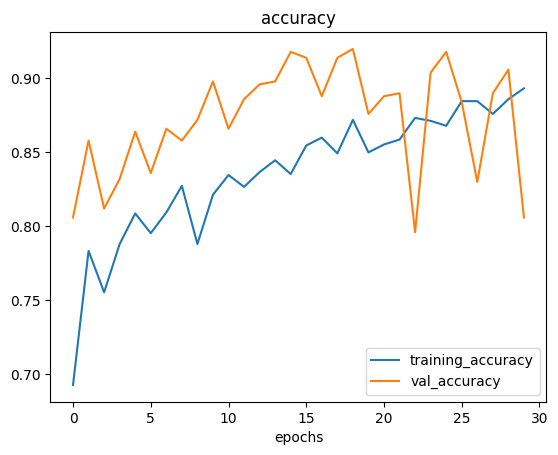

In [ ]:
plot_loss_curves(history)

## Making a prediction with our trained model on custom data

In [ ]:
print(class_names)

['pizza' 'steak']


--2026-05-12 10:35:07--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1978213 (1.9M) [image/jpeg]
Saving to: ‘03-steak.jpeg.1’

03-steak.jpeg.1     100%[===================>]   1.89M  --.-KB/s    in 0.04s   

2026-05-12 10:35:07 (45.2 MB/s) - ‘03-steak.jpeg.1’ saved [1978213/1978213]



(np.float64(-0.5), np.float64(3023.5), np.float64(4031.5), np.float64(-0.5))

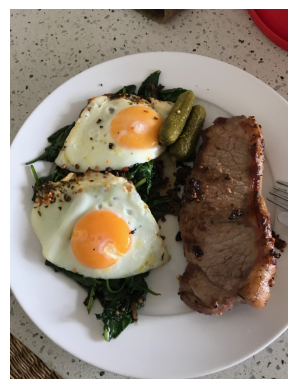

In [ ]:
# view our example image
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg
steak = mpimg.imread('03-steak.jpeg')
plt.imshow(steak)
plt.axis(False)

In [ ]:
def load_and_prep_image(filename, image_shape=224):
  """
  Reads an image from filename, turns it into a tensor and reshapes it to
  (img_shape, img_shape, color_channels)
  """

  # Read in the image
  img = tf.io.read_file(filename)

  # Decode the read file into a tensor
  img = tf.image.decode_image(img)

  #Resize the image
  img = tf.image.resize(img, size=[image_shape,image_shape])

  # Rescale the image (get all the values between 0 and 1)
  img = img/255.
  return img

In [ ]:
# Load in and pre process image
steak = load_and_prep_image('03-steak.jpeg')

In [ ]:
output = model_7.predict(tf.expand_dims(steak, axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [ ]:
pred_class = class_names[round(output[0][0])]
pred_class

In [ ]:
def  pred_and_plot(model, filename, class_names=class_names):
  """
  Import an image located at filename, makes a prediction with model
  and plots the image with the predicted class as teh title.
  """
  # Import the target image and preprocess it
  img = load_and_prep_image(filename)

  pred = model.predict(tf.expand_dims(img, axis=0))

  # Get teh predicted class
  pred_class = class_names[int(tf.round(pred))]

  # Plot the image and predicted class
  plt.imshow(img)
  plt.title(f'Prediction: {pred_class}')
  plt.axis(False)

In [ ]:
# -q is for "quiet"
!wget -q https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-pizza-dad.jpeg
!wget -q https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg
!wget -q https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-hamburger.jpeg
!wget -q https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-sushi.jpeg

In [ ]:
pred_and_plot(model, '03-pizza-dad.jpeg')